<a href="https://colab.research.google.com/github/Srija1902/oasis_dataanalytics_task1/blob/main/Sentiment_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
df = pd.read_csv('/content/Twitter_Data.csv')
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [7]:
df.columns

Index(['clean_text', 'category'], dtype='object')

In [8]:
df.shape

(162980, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [10]:
df.isnull().sum()

,0
clean_text,4
category,7


In [11]:
df.dropna(inplace=True)

In [12]:
df['clean_text'] = df['clean_text'].str.lower()

In [24]:


df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))
)

In [26]:


tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['clean_text'])

y = df['category']

In [25]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:


model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [17]:
y_pred = model.predict(X_test)

In [30]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.578327299502976


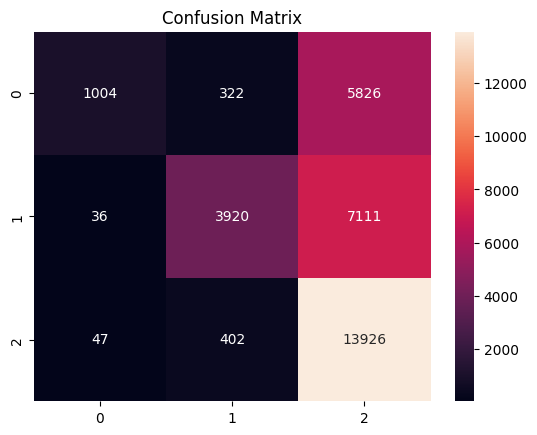

In [31]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.show()

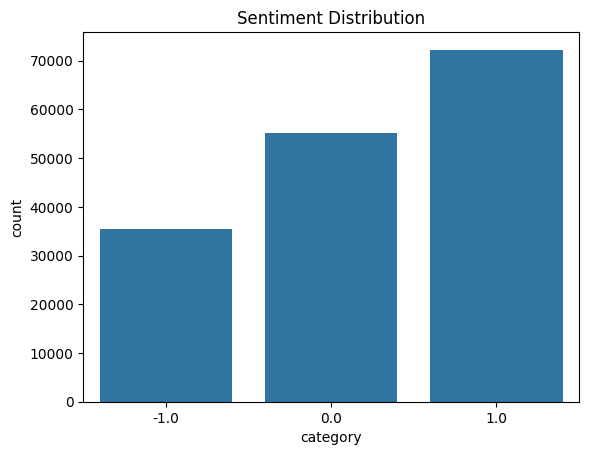

In [20]:
sns.countplot(x='category', data=df)

plt.title('Sentiment Distribution')

plt.show()

In [23]:
sample = ["I hate this service"]

sample_vector = tfidf.transform(sample)

prediction = model.predict(sample_vector)

print(prediction)

[-1.]
